# 11.3 Recurrent neural networks
## 11.3.1 Simulate sequence data

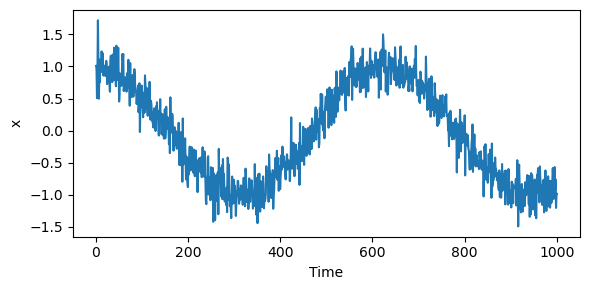

In [ ]:
%matplotlib inline
import torch
import matplotlib.pyplot as plt
# Define sequence length
T = 1000
time = torch.arange(1, T + 1, dtype=torch.float32)
# Generate sequence data: cos wave + Gaussian noise
x = torch.cos(0.01 * time) + torch.normal(0, 0.2, (T,))

plt.figure(figsize=(6, 3))
plt.plot(time.numpy(), x.numpy(), label='Sequence Data')
plt.xlabel('Time')
plt.ylabel('x')
plt.show()

## 11.3.2 Character and word tokenization

In [ ]:
import re

# Example SMILES string and a sentence
smiles = "CCO(C)C"
sentence = "Predicting molecule properties."

# Character tokenization
char_tokens_smiles = list(smiles)
char_tokens_sentence = list(sentence.lower()) # Often convert to lowercase

# Simple word tokenization (split by space and handle punctuation)
def simple_word_tokenize(text):
    # Use regex to split by space and keep punctuation as separate tokens
    # Convert to lowercase
    text = text.lower()
    # Add space around punctuation
    text = re.sub(r'([,.!?()])', r' \1 ', text)
    # Split by whitespace
    return text.split()

word_tokens_sentence = simple_word_tokenize(sentence)

print("SMILES:", smiles)
print("Character Tokens (SMILES):", char_tokens_smiles)
print("\nSentence:", sentence)
print("Character Tokens (Sentence):", char_tokens_sentence)
print("Word Tokens (Sentence):", word_tokens_sentence)

SMILES: CCO(C)C
Character Tokens (SMILES): ['C', 'C', 'O', '(', 'C', ')', 'C']

Sentence: Predicting molecule properties.
Character Tokens (Sentence): ['p', 'r', 'e', 'd', 'i', 'c', 't', 'i', 'n', 'g', ' ', 'm', 'o', 'l', 'e', 'c', 'u', 'l', 'e', ' ', 'p', 'r', 'o', 'p', 'e', 'r', 't', 'i', 'e', 's', '.']
Word Tokens (Sentence): ['predicting', 'molecule', 'properties', '.']


## 11.3.3 Construct a simple vocabulary

In [ ]:
import collections

class Vocab:
    """Simple Vocabulary class."""
    def __init__(self, tokens=[], min_freq=0, reserved_tokens=[]):
        # Flatten token lists if necessary
        if tokens and isinstance(tokens[0], list):
            tokens = [token for line in tokens for token in line]

        # Count token frequencies
        counter = collections.Counter(tokens)
        self.token_freqs = sorted(counter.items(), key=lambda x: x[1], reverse=True)

        # Initialize index-to-token list with unknown and reserved tokens
        self.idx_to_token = ['<unk>'] + reserved_tokens
        # Initialize token-to-index dictionary
        self.token_to_idx = {token: idx for idx, token in enumerate(self.idx_to_token)}

        # Add tokens from corpus if frequency meets threshold
        for token, freq in self.token_freqs:
            if freq >= min_freq and token not in self.token_to_idx:
                self.idx_to_token.append(token)
                self.token_to_idx[token] = len(self.idx_to_token) - 1

    def __len__(self):
        return len(self.idx_to_token)

    def __getitem__(self, tokens):
        # Convert token(s) to index(es)
        if not isinstance(tokens, (list, tuple)):
            return self.token_to_idx.get(tokens, self.unk_idx)
        return [self.__getitem__(token) for token in tokens]

    def to_tokens(self, indices):
        # Convert index(es) to token(s)
        if not isinstance(indices, (list, tuple)):
            return self.idx_to_token[indices]
        return [self.idx_to_token[index] for index in indices]

    @property
    def unk_idx(self):
        # Return the index for the <unk> token
        return self.token_to_idx['<unk>']

# Example Usage: Build vocabulary from word tokens of the sentence
corpus_tokens = [word_tokens_sentence] # Corpus is a list of token lists
reserved = ['<pad>', '<bos>', '<eos>']
vocab = Vocab(corpus_tokens, min_freq=1, reserved_tokens=reserved)

print("\nVocabulary Size:", len(vocab))
print("Index to Token mapping:", vocab.idx_to_token)
print("Token to Index mapping:", vocab.token_to_idx)

# Convert sentence tokens to indices
indices = vocab[word_tokens_sentence]
print("\nOriginal Sentence Tokens:", word_tokens_sentence)
print("Mapped Indices:", indices)

# Convert indices back to tokens
print("Tokens from Indices:", vocab.to_tokens(indices))
# Test unknown token
print("Index for 'unknown_word':", vocab['unknown_word'])
print("Token for index 0:", vocab.to_tokens(0))


Vocabulary Size: 8
Index to Token mapping: ['<unk>', '<pad>', '<bos>', '<eos>', 'predicting', 'molecule', 'properties', '.']
Token to Index mapping: {'<unk>': 0, '<pad>': 1, '<bos>': 2, '<eos>': 3, 'predicting': 4, 'molecule': 5, 'properties': 6, '.': 7}

Original Sentence Tokens: ['predicting', 'molecule', 'properties', '.']
Mapped Indices: [4, 5, 6, 7]
Tokens from Indices: ['predicting', 'molecule', 'properties', '.']
Index for 'unknown_word': 0
Token for index 0: <unk>


## 11.3.4 Implement the operations of RNN cell

In [16]:
import torch

# Example dimensions
batch_size, seq_len, input_size, hidden_size = 2, 3, 4, 5

# Create dummy data for one time step
X_t = torch.randn(batch_size, input_size)
H_prev = torch.randn(batch_size, hidden_size)

# Define weight matrices
W_xh = torch.randn(input_size, hidden_size)
W_hh = torch.randn(hidden_size, hidden_size)

# Method 1: Separate multiplications and addition
output1 = torch.matmul(X_t, W_xh) + torch.matmul(H_prev, W_hh)

# Method 2: Concatenation and single multiplication
X_H_concat = torch.cat((X_t, H_prev), dim=1) # Shape: (batch_size, input_size + hidden_size)
W_xh_hh_concat = torch.cat((W_xh, W_hh), dim=0) # Shape: (input_size + hidden_size, hidden_size)
output2 = torch.matmul(X_H_concat, W_xh_hh_concat)

# Check if results are close (within numerical tolerance)
print("Are outputs equal?", torch.allclose(output1, output2))
print("Output 1 shape:", output1.shape)
print("Output 2 shape:", output2.shape)

Are outputs equal? True
Output 1 shape: torch.Size([2, 5])
Output 2 shape: torch.Size([2, 5])


## 11.3.5 Implement a basic RNN layer

In [17]:
import torch
import torch.nn as nn

# Define parameters
input_size = 10  # Example: Size of input features
hidden_size = 20 # Example: Number of hidden units
num_layers = 1   # We use 1 for the basic RNN described above
batch_size = 5   # Example: Number of sequences in a batch
seq_len = 7      # Example: Length of each sequence

# Instantiate the basic RNN layer
# Note: batch_first=False is the default, expecting input shape (seq_len, batch_size, input_size)
rnn_layer = nn.RNN(input_size, hidden_size, num_layers)

X = torch.randn(seq_len, batch_size, input_size)

# Initialize the hidden state (optional, defaults to zeros if None)
# Shape: (num_layers, batch_size, hidden_size)
h0 = torch.zeros(num_layers, batch_size, hidden_size)

# Forward pass through the RNN layer
# `output` contains the hidden state output for *each* time step
# `hn` contains the *final* hidden state (for the last time step)
output, hn = rnn_layer(X, h0)
# If h0 is omitted: output, hn = rnn_layer(X)

print("Input shape:", X.shape)
print("Initial hidden state shape:", h0.shape)
print("Output shape (all time steps):", output.shape) # (seq_len, batch_size, hidden_size)
print("Final hidden state shape:", hn.shape)         # (num_layers, batch_size, hidden_size)

Input shape: torch.Size([7, 5, 10])
Initial hidden state shape: torch.Size([1, 5, 20])
Output shape (all time steps): torch.Size([7, 5, 20])
Final hidden state shape: torch.Size([1, 5, 20])


## 11.3.6 Implement a LSTM layer

In [ ]:
import torch
import torch.nn as nn

# Define parameters
input_size = 10  # Size of input features
hidden_size = 20 # Number of hidden units
num_layers = 1   # Number of recurrent layers
batch_size = 5   # Number of sequences in a batch
seq_len = 7      # Length of each sequence

# Instantiate the LSTM layer
lstm_layer = nn.LSTM(input_size, hidden_size, num_layers)

# Create some dummy input data
# Shape: (seq_len, batch_size, input_size)
X = torch.randn(seq_len, batch_size, input_size)

# Initialize the hidden state and cell state
# Shape for both h0 and c0: (num_layers, batch_size, hidden_size)
h0 = torch.zeros(num_layers, batch_size, hidden_size)
c0 = torch.zeros(num_layers, batch_size, hidden_size)

# Forward pass through the LSTM layer
# The LSTM layer takes a tuple of (h0, c0) as the initial state
# If (h0, c0) is omitted, it defaults to zeros: output, (hn, cn) = lstm_layer(X)
output, (hn, cn) = lstm_layer(X, (h0, c0))
# If (h0, c0) is omitted, it defaults to zeros: output, (hn, cn) = lstm_layer(X)

print("Input shape:", X.shape)
print("Initial hidden state shape (h0):", h0.shape)
print("Initial cell state shape (c0):", c0.shape)
print("\nOutput shape (all hidden states H_t):", output.shape) # (seq_len, batch_size, hidden_size)
print("Final hidden state shape (hn):", hn.shape)         # (num_layers, batch_size, hidden_size)
print("Final cell state shape (cn):", cn.shape)           # (num_layers, batch_size, hidden_size)

Input shape: torch.Size([7, 5, 10])
Initial hidden state shape (h0): torch.Size([1, 5, 20])
Initial cell state shape (c0): torch.Size([1, 5, 20])

Output shape (all hidden states H_t): torch.Size([7, 5, 20])
Final hidden state shape (hn): torch.Size([1, 5, 20])
Final cell state shape (cn): torch.Size([1, 5, 20])


## 11.3.7 Implement a GRU layer

In [ ]:
import torch
import torch.nn as nn

# Define parameters
input_size = 10  # Size of input features (d)
hidden_size = 20 # Number of hidden units (h)
num_layers = 1   # Number of recurrent layers
batch_size = 5   # Number of sequences in a batch (n)
seq_len = 7      # Length of each sequence (T)

# Instantiate the GRU layer
gru_layer = nn.GRU(input_size, hidden_size, num_layers)

# Create some dummy input data
# Shape: (seq_len, batch_size, input_size) -> (T, n, d)
X = torch.randn(seq_len, batch_size, input_size)

# Initialize the hidden state (optional, defaults to zeros if None)
# Shape: (num_layers, batch_size, hidden_size) -> (num_layers, n, h)
h0 = torch.zeros(num_layers, batch_size, hidden_size)

# Forward pass through the GRU layer
# GRU returns the output (all hidden states) and the final hidden state (hn)
output, hn = gru_layer(X, h0)
# If h0 is omitted: output, hn = gru_layer(X)

print("Input shape (X):", X.shape) # (T, n, d)
print("Initial hidden state shape (H_0):", h0.shape) # (num_layers, n, h)
print("\nOutput shape (all H_t):", output.shape) # (T, n, h)
print("Final hidden state shape (H_T):", hn.shape) # (num_layers, n, h)

Input shape (X): torch.Size([7, 5, 10])
Initial hidden state shape (H_0): torch.Size([1, 5, 20])

Output shape (all H_t): torch.Size([7, 5, 20])
Final hidden state shape (H_T): torch.Size([1, 5, 20])


## 11.3.8 Implement a Bidirectional RNN layer

In [ ]:
import torch
import torch.nn as nn

# Define parameters
input_size = 10  # Size of input features (d)
hidden_size = 20 # Number of hidden units per direction (h)
num_layers = 1   # Number of recurrent layers (can be > 1 for deep BiRNN)
batch_size = 5   # Number of sequences in a batch (n)
seq_len = 7      # Length of each sequence (T)

# Instantiate a bidirectional GRU layer
# Note: hidden_size specifies the size for *each* direction.
# The combined hidden state will have size 2 * hidden_size.
bi_gru_layer = nn.GRU(input_size, hidden_size, num_layers, bidirectional=True)

# Create some dummy input data
X = torch.randn(seq_len, batch_size, input_size)

# Initialize the hidden state (optional, defaults to zeros)
# Shape: (num_layers * 2, batch_size, hidden_size) -> (num_layers * num_directions, n, h)
# The first `num_layers` dimensions are for the forward RNN,
# the next `num_layers` are for the backward RNN.
h0 = torch.zeros(num_layers * 2, batch_size, hidden_size)

# Forward pass
# `hn` contains the final hidden states from both directions
output, hn = bi_gru_layer(X, h0)

print("Input shape (X):", X.shape) # (T, n, d)
print("Initial hidden state shape (H_0):", h0.shape) # (num_layers*2, n, h)
print("\nOutput shape (all concatenated H_t):", output.shape) # (T, n, 2*h)
print("Final hidden state shape (hn):", hn.shape) # (num_layers*2, n, h)

# Access final forward and backward states from hn (for num_layers=1)
final_h_fwd = hn[0, :, :] # Shape: (n, h)
final_h_bwd = hn[1, :, :] # Shape: (n, h)
print("\nShape of final forward state:", final_h_fwd.shape)
print("Shape of final backward state:", final_h_bwd.shape)

## 11.3.9 Implement a Seq2Seq model based on the Encoder-Decoder architecture

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class EncoderDecoder(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
    def forward(self, enc_X, dec_X, *args):
        enc_outputs = self.encoder(enc_X, *args)
        dec_state = self.decoder.init_state(enc_outputs, *args)
        return self.decoder(dec_X, dec_state)[0]

# --- Simple RNN Implementation (Seq2SeqEncoder, Seq2SeqDecoder - defined as before) ---
class Seq2SeqEncoder(nn.Module):
    def __init__(self, vocab_size, embed_size, num_hiddens, num_layers, dropout=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.GRU(embed_size, num_hiddens, num_layers, dropout=dropout)
    def forward(self, X, *args): # X shape: (batch_size, enc_seq_len)
        embs = self.embedding(X.t().type(torch.int64)) # embs shape: (enc_seq_len, batch_size, embed_size)
        outputs, state = self.rnn(embs) # outputs: (enc_seq_len, batch_size, num_hiddens), state: (num_layers, batch_size, num_hiddens)
        return outputs, state

class Seq2SeqDecoder(nn.Module):
    def __init__(self, vocab_size, embed_size, num_hiddens, num_layers, dropout=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.GRU(embed_size + num_hiddens, num_hiddens, num_layers, dropout=dropout)
        self.dense = nn.Linear(num_hiddens, vocab_size)
    def init_state(self, enc_outputs, *args):
        return enc_outputs[1] # Use final encoder hidden state
    def forward(self, X, state): # X shape: (batch_size, dec_seq_len)
        embs = self.embedding(X.t().type(torch.int64)) # embs shape: (dec_seq_len, batch_size, embed_size)
        context = state[-1].repeat(embs.shape[0], 1, 1) # context: (dec_seq_len, batch_size, num_hiddens)
        embs_and_context = torch.cat((embs, context), dim=2) # Concat: (dec_seq_len, batch_size, embed_size + num_hiddens)
        outputs, state = self.rnn(embs_and_context, state) # outputs: (dec_seq_len, batch_size, num_hiddens)
        outputs = self.dense(outputs) # outputs: (dec_seq_len, batch_size, vocab_size)
        probs = F.softmax(outputs, dim=2)
        return probs.permute(1, 0, 2), state # Final outputs: (batch_size, dec_seq_len, vocab_size)


# Define hyperparameters
vocab_size_src, vocab_size_tgt = 100, 120
embed_size, num_hiddens, num_layers = 32, 32, 2
batch_size = 4
enc_seq_len = 10 # Length of input sequences
dec_seq_len = 8  # Length of output sequences

# Instantiate the components
encoder = Seq2SeqEncoder(vocab_size_src, embed_size, num_hiddens, num_layers)
decoder = Seq2SeqDecoder(vocab_size_tgt, embed_size, num_hiddens, num_layers)
seq2seq_model = EncoderDecoder(encoder, decoder)

enc_X = torch.randint(0, vocab_size_src, (batch_size, enc_seq_len))
dec_X = torch.randint(0, vocab_size_tgt, (batch_size, dec_seq_len)) # Decoder input (e.g., <bos> + target shifted)

# Output `output_probs` will have shape: (batch_size, dec_seq_len, vocab_size_tgt)
output_probs = seq2seq_model(enc_X, dec_X)

print("Encoder Input Shape (enc_X):", enc_X.shape)
print("Decoder Input Shape (dec_X):", dec_X.shape)
print("Model Output Shape (output_probs):", output_probs.shape)

Encoder Input Shape (enc_X): torch.Size([4, 10])
Decoder Input Shape (dec_X): torch.Size([4, 8])
Model Output Shape (output_probs): torch.Size([4, 8, 120])


## 11.3.10 Build a beam search function

In [42]:
import torch
import torch.nn.functional as F

# Assume vocabulary size
vocab_size = 6
eos_token = 5  # Define <eos> token

# Dummy decoder: given previous token, output next token probability distribution
class DummyDecoder:
    def __init__(self):
        pass
    def step(self, prev_token):
        # Randomly generate probability distribution (in practice, use model output)
        logits = torch.randn(vocab_size)
        probs = F.softmax(logits, dim=0)
        return probs

def beam_search(decoder, beam_size=2, max_len=5, bos_token=0, alpha=0.75):
    beams = [(0.0, [bos_token])]  # (cumulative log probability, token sequence)
    for _ in range(max_len):
        new_beams = []
        for score, seq in beams:
            if seq[-1] == eos_token:
                # If <eos> is reached, do not expand this sequence
                new_beams.append((score, seq))
                continue
            probs = decoder.step(seq[-1])  # Get probability distribution for next token
            topk_probs, topk_idx = probs.topk(beam_size)  # Select top-k tokens
            for prob, idx in zip(topk_probs, topk_idx):
                new_score = score + torch.log(prob).item()  # Update cumulative log probability
                new_seq = seq + [idx.item()]  # Append new token to sequence
                new_beams.append((new_score, new_seq))
        # Length penalty: sort by (score / (len(seq) ** alpha))
        beams = sorted(
            new_beams,
            key=lambda x: x[0] / (len(x[1]) ** alpha),
            reverse=True
        )[:beam_size]  # Keep top beam_size sequences
    return beams

# Demo
decoder = DummyDecoder()
results = beam_search(decoder, beam_size=2, max_len=5, bos_token=0)
for score, seq in results:
    print(f"Score: {score:.2f}, Sequence: {seq}")

Score: -3.55, Sequence: [0, 4, 2, 1, 1, 0]
Score: -4.12, Sequence: [0, 4, 2, 1, 1, 4]
